In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import replace

from src.config import SimulationConfig
from src.simulator import run_simulation
from src.disorder import generate_breakdown_strength

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    random_seed=42,
    disorder_seed=123,
)

weibull_shapes = [2.0, 5.0, 15.0]

results = []

for k in weibull_shapes:
    config = replace(
        base_config,
        weibull_shape=k,
    )

    field, history, breakdown = run_simulation(config)

    strength = generate_breakdown_strength(
        ny=config.ny,
        nx=config.nx,
        correlation_length=config.correlation_length,
        weibull_shape=config.weibull_shape,
        seed=config.disorder_seed,
    )

    results.append(
        (config, field, history, breakdown, strength)
    )

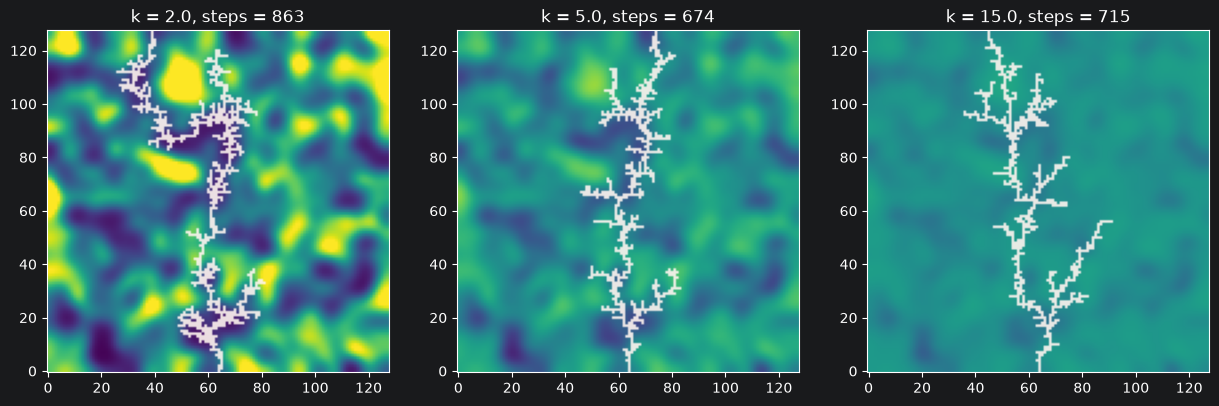

In [3]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

for ax, (config, field, history, breakdown, strength) in zip(
    axes,
    results,
):
    ax.imshow(
        strength,
        origin="lower",
        vmin=0.0,
        vmax=2.0,
    )

    channel = np.ma.masked_where(
        ~field.channel,
        field.channel,
    )

    ax.imshow(
        channel,
        origin="lower",
        cmap="Reds",
        alpha=0.9,
    )

    ax.set_title(
        f"k = {config.weibull_shape}, "
        f"steps = {len(history)}"
    )

plt.show()

In [4]:
for config, field, history, breakdown, strength in results:
    mean_material_strength = strength.mean()
    mean_channel_strength = strength[field.channel].mean()

    print(
        f"k={config.weibull_shape:>4}: "
        f"material={mean_material_strength:.3f}, "
        f"channel={mean_channel_strength:.3f}, "
        f"steps={len(history)}, "
        f"breakdown={breakdown}"
    )

k= 2.0: material=1.000, channel=0.567, steps=863, breakdown=True
k= 5.0: material=1.000, channel=0.885, steps=674, breakdown=True
k=15.0: material=1.000, channel=0.991, steps=715, breakdown=True


In [5]:
from src.config import SimulationConfig
from src.field import ElectricField
from src.disorder import generate_breakdown_strength
from src.growth import get_front

config = SimulationConfig
field = ElectricField(config)
strength = generate_breakdown_strength(
    ny=config.ny,
    nx=config.nx,
    correlation_length=config.correlation_length,
    weibull_shape=config.weibull_shape,
    seed=config.disorder_seed,
)
field.solve_laplace_sor()
_, _, E = field.electric_field()
front = get_front(field.channel)
E_front = E[front]
S_front = strength[front]
Ebd_front = (
    config.mean_breakdown_field
    * S_front
)
ratio = E_front / Ebd_front
print("E:", E_front)
print("S:", S_front)
print("E_bd:", Ebd_front)
print("E / E_bd:", ratio)
print("active cells:", np.sum(ratio > 1.0))

E: [1.]
S: [0.98626421]
E_bd: [0.69038495]
E / E_bd: [1.44846727]
active cells: 1


In [6]:
config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    weibull_shape=5.0,
    mean_breakdown_field=0.7,
    random_seed=42,
    disorder_seed=123,
)

field, history, breakdown = run_simulation(config)

print("steps:", len(history))
print("breakdown:", breakdown)

steps: 674
breakdown: True


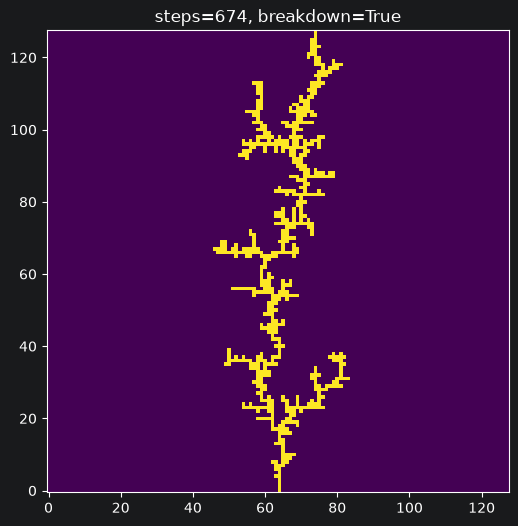

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(
    field.channel,
    origin="lower",
)

plt.title(
    f"steps={len(history)}, breakdown={breakdown}"
)

plt.show()

In [11]:
thresholds = [
    1.10,
    1.12,
    1.14,
    1.145,
    1.15,
    1.16,
    1.18,
    1.20,
]
results = []

for threshold in thresholds:
    config = SimulationConfig(
        nx=128,
        ny=128,
        eta=1.5,
        correlation_length=5.0,
        weibull_shape=5.0,
        mean_breakdown_field=threshold,
        random_seed=42,
        disorder_seed=123,
    )

    field, history, breakdown = run_simulation(config)

    results.append({
        "threshold": threshold,
        "steps": len(history),
        "breakdown": breakdown,
    })

    print(
        f"E_bd0={threshold:.3f}: "
        f"steps={len(history)}, "
        f"breakdown={breakdown}"
    )

    

E_bd0=1.1: steps=662, breakdown=True
E_bd0=1.1: steps=616, breakdown=True
E_bd0=1.1: steps=657, breakdown=True
E_bd0=1.1: steps=649, breakdown=True
E_bd0=1.1: steps=0, breakdown=False
E_bd0=1.2: steps=0, breakdown=False
E_bd0=1.2: steps=0, breakdown=False
E_bd0=1.2: steps=0, breakdown=False
